In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata
import scanpy as sc
import leidenalg
import squidpy as sq
from scipy import sparse
from matplotlib.colors import ListedColormap
import os
import numpy as np
import pandas as pd
from scipy.spatial import KDTree
from tqdm import tqdm
import seaborn as sns
import geopandas as gpd
from scipy.io import mmread
from scipy.spatial.distance import pdist
from scipy.stats import entropy
#ignore warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.decomposition import PCA

In [2]:
def compute_tsps(adata, cell_type_col="tumor_state", spatial_key="spatial", radius=500):
    """
    Compute the Tumor State Proximity Score (TSPS) for each tumor cell and each tumor state.

    Parameters:
        adata: AnnData
            The AnnData object containing spatial coordinates and tumor state annotations.
        cell_type_col: str
            The column in `adata.obs` containing tumor state labels.
        spatial_key: str
            The key in `adata.obsm` containing spatial coordinates.
        radius: float
            The radius (in spatial units) within which to consider neighboring cells.
        num_permutations: int
            Number of permutations for null distribution in significance testing.

    Returns:
        tsps_per_cell: np.ndarray
            TSPS values for each tumor cell.
        tsps_per_state: dict
            TSPS averaged per tumor state.
        p_values: dict
            P-values for each tumor state based on permutation testing.
    """
    
    # Extract spatial coordinates and tumor state labels
    if spatial_key not in adata.obsm:
        raise ValueError(f"Spatial key '{spatial_key}' not found in `adata.obsm`.")
    if cell_type_col not in adata.obs:
        raise ValueError(f"Cell type column '{cell_type_col}' not found in `adata.obs`.")

    coords = adata.obsm[spatial_key]
    tumor_states = adata.obs[cell_type_col].values
    unique_states = np.unique(tumor_states)

    # Build KDTree for efficient nearest-neighbor search
    kd_tree = KDTree(coords)

    # Compute per-cell TSPS
    tsps_per_cell = np.zeros(len(coords))
    
    for i in tqdm(range(len(coords)), desc="Computing per-cell TSPS"):
        neighbors_idx = kd_tree.query_ball_point(coords[i], radius)
        neighbors_idx = [j for j in neighbors_idx if j != i]  # Exclude self
        
        if len(neighbors_idx) > 0:
            same_state_count = sum(tumor_states[j] == tumor_states[i] for j in neighbors_idx)
            tsps_per_cell[i] = same_state_count / len(neighbors_idx)
        else:
            tsps_per_cell[i] = np.nan  # No neighbors within radius

    # Compute per-state TSPS
    tsps_per_state = {}
    for state in unique_states:
        state_indices = np.where(tumor_states == state)[0]
        tsps_per_state[state] = np.nanmean(tsps_per_cell[state_indices])

    return tsps_per_cell, tsps_per_state

Processing patient: Pat03_W0
Skipping Pat03_W0: not enough cells or MP not found
Processing patient: Pat03_W4


Computing per-cell TSPS: 100%|██████████| 18131/18131 [00:15<00:00, 1151.74it/s]


Computing within-group correlations for MP7_clustered
Computing within-group correlations for MP7_dispersed


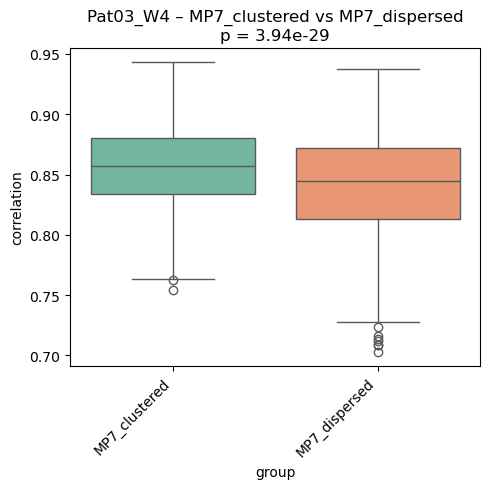

Processing patient: Pat06_W0
Skipping Pat06_W0: not enough cells or MP not found
Processing patient: Pat06_W4


Computing per-cell TSPS: 100%|██████████| 51276/51276 [00:54<00:00, 939.02it/s] 


Computing within-group correlations for MP7_clustered
Computing within-group correlations for MP7_dispersed


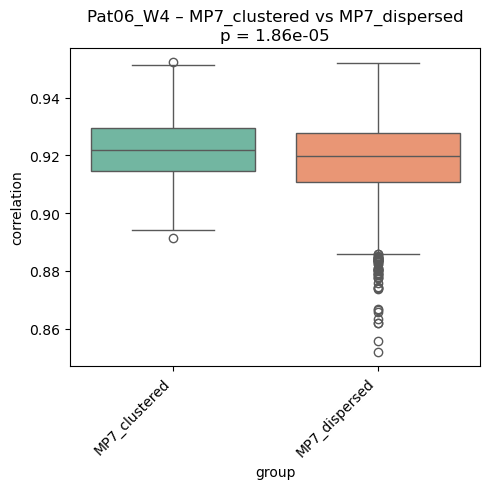

Processing patient: Pat14_W0


Computing per-cell TSPS: 100%|██████████| 78716/78716 [01:43<00:00, 757.00it/s] 


Computing within-group correlations for MP7_clustered
Computing within-group correlations for MP7_dispersed


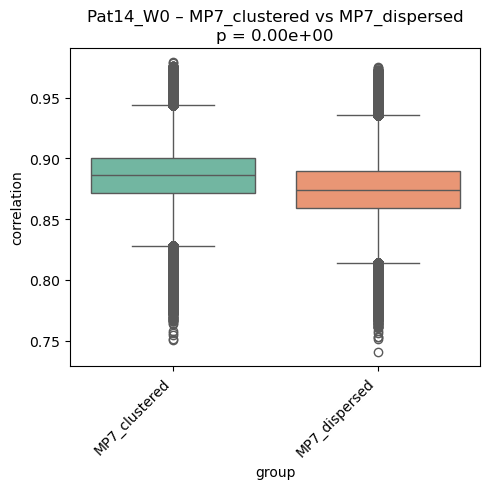

Processing patient: Pat14_W12


Computing per-cell TSPS: 100%|██████████| 117599/117599 [02:58<00:00, 658.91it/s]


Computing within-group correlations for MP7_clustered
Computing within-group correlations for MP7_dispersed


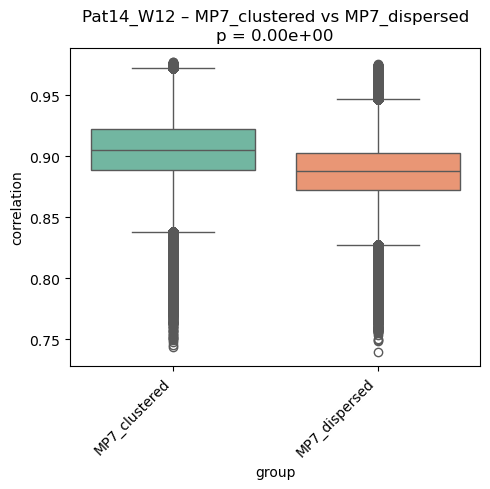

Processing patient: Pat14_W4


Computing per-cell TSPS: 100%|██████████| 14624/14624 [00:27<00:00, 530.30it/s]


Computing within-group correlations for MP7_clustered
Computing within-group correlations for MP7_dispersed


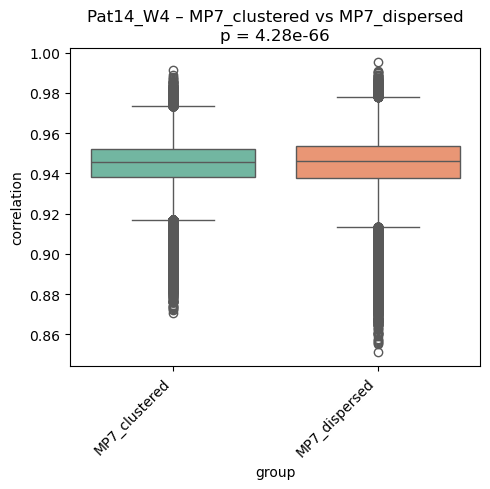

Processing patient: Pat2_W12


Computing per-cell TSPS: 100%|██████████| 34401/34401 [00:44<00:00, 772.61it/s] 


Computing within-group correlations for MP7_clustered
Computing within-group correlations for MP7_dispersed


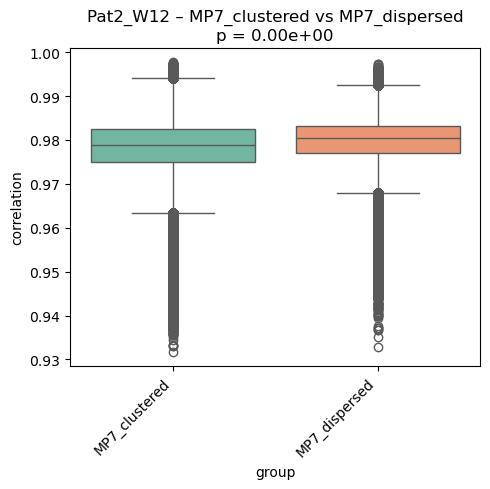

Processing patient: Pat2_W4


Computing per-cell TSPS: 100%|██████████| 19322/19322 [00:15<00:00, 1232.45it/s]


Computing within-group correlations for MP7_clustered
Computing within-group correlations for MP7_dispersed


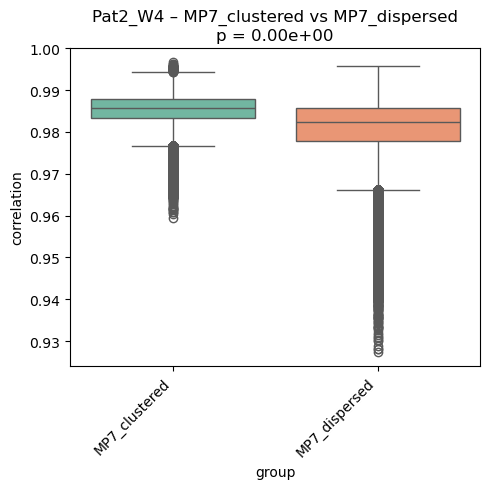

In [23]:
from scipy.stats import pearsonr
from itertools import combinations
import itertools
from collections import defaultdict
from scipy.stats import mannwhitneyu
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

all_group_corrs = []
mp_interest = "MP_7"

os.chdir('/home/fceccarelli/home3/OT_simulation/code/VisiumHD/segmentation')
group_labels = [f"{mp_interest.replace('MP_', 'MP')}_clustered", f"{mp_interest.replace('MP_', 'MP')}_dispersed"]
pca = False


#read all folders in the directory
folders = [x for x in os.listdir() if os.path.isdir(x)]
folders.sort()
all_tsps = defaultdict(list)
all_pvals = defaultdict(list)

for folder in folders:
    print(f"Processing patient: {folder}")
    try:
        adata = anndata.read_h5ad(folder + "/" + folder + "_008_programs.h5ad")
        if ("Pat03" in folder) or ("Pat14" in folder):
            sc.pp.scale(adata)
    except:
        print(f"Error reading {folder}")
        continue

    if (mp_interest not in adata.obs["cell_type"].values) or (adata.obs["cell_type"].str.startswith(mp_interest).sum() < 50):
        print(f"Skipping {folder}: not enough cells or MP not found")
        continue

    # Keep only tumor cells
    adata = adata[adata.obs["cell_type"].str.startswith("MP"), :]

    # Compute TSPS and p-values
    tsps_per_cell, _ = compute_tsps(adata, "cell_type")
    tsps_labels = np.full_like(tsps_per_cell, "neutral", dtype=object)

    for mp in adata.obs["cell_type"].unique():
        if not mp.startswith("MP_"):
            continue
        mask = (adata.obs["cell_type"] == mp)
        tsps_vals = tsps_per_cell[mask]
        
        if np.sum(mask) < 5:  # skip tiny groups
            continue

        q25 = np.nanpercentile(tsps_vals, 25)
        q75 = np.nanpercentile(tsps_vals, 75)

        tsps_labels[mask & (tsps_per_cell >= q75)] = "clustered"
        tsps_labels[mask & (tsps_per_cell <= q25)] = "dispersed"
    
    # Add the TSPS values and label to the adata object
    adata.obs["TSPS"] = tsps_per_cell
    adata.obs["TSPS_status"] = tsps_labels
    
    # Select clustered and dispersed for the specific MP
    mp_label = mp_interest.replace("MP_", "MP")
    groups = {
        f"{mp_label}_clustered": adata[(adata.obs["cell_type"] == mp_interest) & (adata.obs["TSPS_status"] == "clustered")],
        f"{mp_label}_dispersed": adata[(adata.obs["cell_type"] == mp_interest) & (adata.obs["TSPS_status"] == "dispersed")]
    }

    within_group_corrs = {}
    for group_name, group_data in groups.items():
        print(f"Computing within-group correlations for {group_name}")
        
        # Ensure dense format
        X = group_data.X.toarray() if hasattr(group_data.X, "toarray") else group_data.X
        
        if X.shape[0] < 2:
            print(f"Skipping {group_name}: not enough cells")
            within_group_corrs[group_name] = []
            continue

        X_centered = X - X.mean(axis=1, keepdims=True)  # Center each cell’s expression

        rho, _ = spearmanr(X_centered, axis=1)
        triu_indices = np.triu_indices_from(rho, k=1)
        within_group_corrs[group_name] = rho[triu_indices]

    group_corr_df = pd.DataFrame([
    {"group": group, "correlation": corr, "patient": folder}
    for group, values in within_group_corrs.items()
    for corr in values])

    all_group_corrs.append(group_corr_df)

    # === Per-patient boxplot for selected MP ===
    mp_label = mp_interest.replace("MP_", "MP")
    group_a = f"{mp_label}_clustered"
    group_b = f"{mp_label}_dispersed"

    # Filter for this MP only
    subset_df = group_corr_df[group_corr_df["group"].isin([group_a, group_b])]

    # if len(subset_df) >= 2:
    #     # Get the values for each group
    #     vals_a = subset_df[subset_df["group"] == group_a]["correlation"]
    #     vals_b = subset_df[subset_df["group"] == group_b]["correlation"]

    #     try:
    #         stat, pval = mannwhitneyu(vals_a, vals_b, alternative="two-sided")
    #     except ValueError:
    #         pval = np.nan

    #     plt.figure(figsize=(5, 5))
    #     sns.boxplot(data=subset_df, x="group", y="correlation", palette="Set2")
    #     plt.title(f"{folder} – {group_a} vs {group_b}\np = {pval:.2e}")
    #     plt.xticks(rotation=45, ha="right")
    #     plt.tight_layout()
    #     plt.show()

In [24]:
group_corr_df_all = pd.concat(all_group_corrs, ignore_index=True)
summary_stats = group_corr_df_all.groupby("group")["correlation"].describe()
print(summary_stats)

                    count      mean       std       min       25%       50%  \
group                                                                         
MP7_clustered  34138661.0  0.923713  0.042771  0.743397  0.889408  0.914176   
MP7_dispersed  27212859.0  0.896403  0.039955  0.702988  0.870104  0.887991   

                    75%       max  
group                              
MP7_clustered  0.973911  0.997679  
MP7_dispersed  0.909567  0.997316  


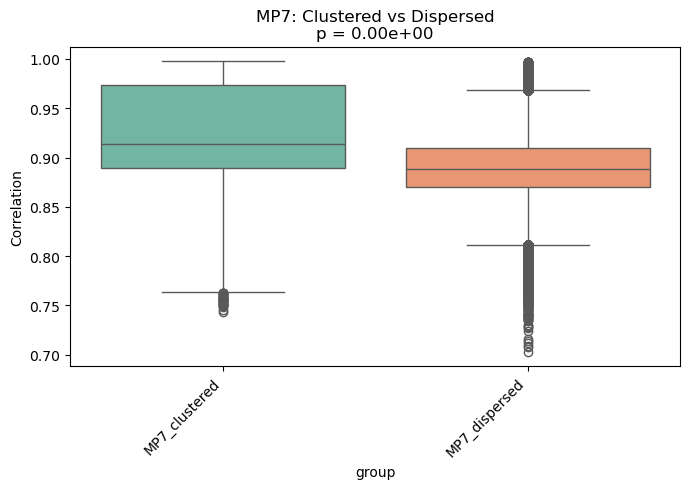

In [25]:
# Plot MP-specific boxplot
plt.figure(figsize=(7, 5))
sns.boxplot(data=group_corr_df_all, x="group", y="correlation", palette="Set2")

# P-value
vals_a = group_corr_df_all[group_corr_df_all["group"] == f"{mp_label}_clustered"]["correlation"]
vals_b = group_corr_df_all[group_corr_df_all["group"] == f"{mp_label}_dispersed"]["correlation"]
stat, pval = mannwhitneyu(vals_a, vals_b, alternative="two-sided")

plt.title(f"{mp_label}: Clustered vs Dispersed\np = {pval:.2e}")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

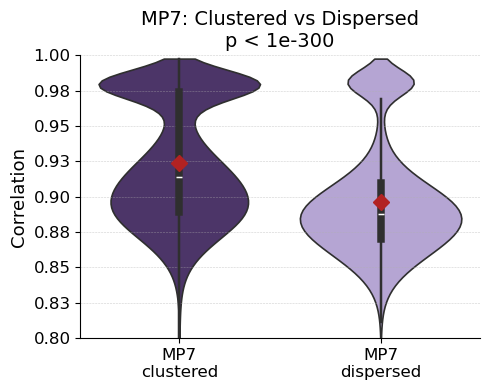

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import mannwhitneyu

# === Define color palette (Clustered = darker green, Dispersed = lighter green)
#MP4
#colors = ["#8BC34A", "#DCEDC8"]
#MP7
colors = ["#4B2C70", "#B39DDB"]

# === Filter and check groups
subset_df = group_corr_df_all[group_corr_df_all["group"].isin([group_a, group_b])].copy()

# Optional: enforce ordering
subset_df["group"] = pd.Categorical(subset_df["group"], categories=[group_a, group_b], ordered=True)

# === Mann–Whitney U test
vals_a = subset_df[subset_df["group"] == group_a]["correlation"]
vals_b = subset_df[subset_df["group"] == group_b]["correlation"]
try:
    stat, pval = mannwhitneyu(vals_a, vals_b, alternative="two-sided")
except ValueError:
    pval = np.nan
pval_str = "p < 1e-300" if pval < 1e-300 else f"p = {pval:.1e}"

# === Plot
plt.figure(figsize=(5, 4))
sns.violinplot(
    data=subset_df,
    x="group",
    y="correlation",
    palette=colors,
    inner="box",
    linewidth=1.2,
    cut=0,
    bw=0.2  # sharpens the shape
)

# === Add red diamond means + optional value labels
means = subset_df.groupby("group")["correlation"].mean()
positions = [0, 1]
for pos, group in zip(positions, [group_a, group_b]):
    mean_val = means[group]
    plt.plot(pos, mean_val, marker='D', color='firebrick', markersize=8, zorder=10)

# === Aesthetic tweaks
plt.title(f"{mp_label}: Clustered vs Dispersed\n{pval_str}", fontsize=14,)
plt.ylabel("Correlation", fontsize=13)
plt.xlabel("")
plt.xticks([0, 1], [group_a.replace("_", "\n"), group_b.replace("_", "\n")], ha="center", fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(0.8, 1)  # Consistent scale
plt.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.6)
from matplotlib.ticker import FormatStrFormatter
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Format y-axis
sns.despine()
plt.tight_layout()

# === Save
plt.savefig(f"Spearman_{mp_label}_violin.pdf", format="pdf", bbox_inches="tight")
plt.show()